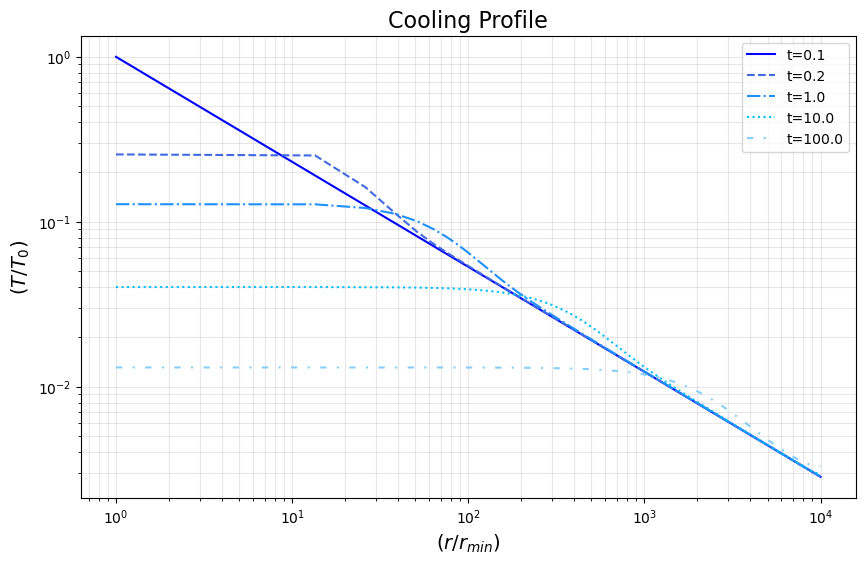

In [50]:
#  pde : d(T^4)/dt = (c/r^2) * d/dr [ (r^2/T) * d(T^4)/dr ]

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# --- Parameters ---
c = 100.0 # C is the diffusive constant. This is not physically relevant. the equation has a symmetry c * t = invariant.
r_min = 1.0 # Left boundary
r_max = 10**4. # right boundary
Nr = 800 
dr = (r_max - r_min) / (Nr - 1)
r = np.linspace(r_min, r_max, Nr)

# Initial Condition at the end of the BH decay : T = r^(-7/11)
T_0 = 1.0 # not associated to any physical scale, we just want to understand the evolution and scaling behavior
T_ini = T_0 * (r_min / r)**(7/11)

def heat_equation(t, T, c_coeff):
    """
    Calculates dT/dt for a non-linear heat equation.
    pde : d(T^4)/dt = (c/r^2) * d/dr [ (r^2/T) * d(T^4)/dr ]
    """
    T_safe = np.maximum(T, 1e-10) # to avoid instability due to small numbers
    T4 = T_safe**4
    
    # 1. Calculate Flux at cell interfaces (size Nr-1)
    # flux = (r^2 / T) * d(T^4)/dr
    r_face = (r[1:] + r[:-1]) / 2.0
    T_face = (T_safe[1:] + T_safe[:-1]) / 2.0
    
    # d(T^4)/dr at the interfaces
    dT4_dr = np.diff(T4) / dr
    
    flux = (r_face**2 / T_face) * dT4_dr
    
    # 2. Apply Boundary Conditions (No Flux at r_min and r_max due to no heat source and no outside influence)
    # Pad the flux array with 0s at both the ends
    full_flux = np.concatenate([[0.0], flux, [0.0]])
    
    # 3. Calculate Divergence of Flux at cell centers (size Nr)
    # div = (1/dr) * [J_right - J_left]
    flux_div = np.diff(full_flux) / dr
    
    # 4. d(T^4)/dt = (c / r^2) * flux_div
    dT4dt = (c_coeff / r**2) * flux_div
    
    # 5. Convert back to dT/dt: dT/dt = (dT4/dt) / (4 * T^3)
    dTdt = dT4dt / (4.0 * T_safe**3)
    
    return dTdt

# --- Integration ---
t_span = (0.1, 100)
t_points = np.array([0.1, 0.2, 1.0, 10.0, 100.]) # Avoid t=0 to prevent initial transient issues

# Using 'Radau' because non-linear diffusion is often a "stiff" problem
solution = solve_ivp(heat_equation, t_span, T_ini, method='Radau', 
                     t_eval=t_points, args=(c,))

# --- Plotting ---
plt.figure(figsize=(10, 6))
colors = ['#0000FF', '#4169E1', '#1E90FF', '#00BFFF', '#87CEFA']
styles = ['solid', 'dashed', 'dashdot', 'dotted', (0, (3, 5, 1, 5))]


# solution.y is shaped (Nr, len(t_points))
for i in range(len(t_points)):
    plt.loglog(r, solution.y[:, i], color=colors[i], linestyle=styles[i], 
               label=f"t={t_points[i]}")

plt.xlabel(r"$(r/r_{min})$", fontsize=14)
plt.ylabel(r"$(T/T_0)$", fontsize=14)
plt.title("Cooling Profile", fontsize=16)
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

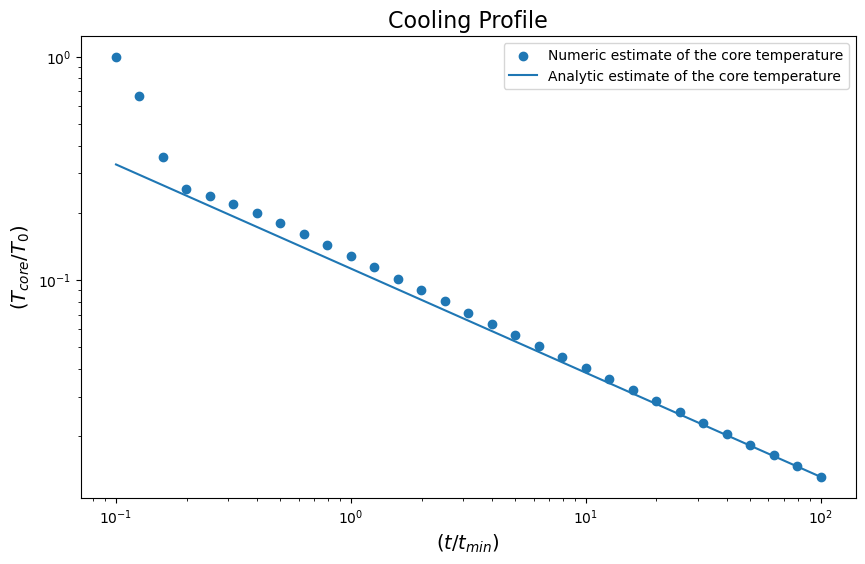

In [48]:
# --- Integration ---
tau = np.linspace(-1,2,31)
t_for_scaling = 10**(tau)

# Use 'Radau' because non-linear diffusion is often "stiff" 
solution = solve_ivp(heat_equation, t_span, T_ini, method='Radau', 
                     t_eval=t_for_scaling, args=(c,))
core_temperature = [solution.y[0, i] for i in range(len(t_for_scaling))]

# --- Plotting ---
plt.figure(figsize=(10, 6))

plt.scatter(t_for_scaling, core_temperature)
plt.plot(t_for_scaling, core_temperature[-1]*(t_for_scaling[-1]/t_for_scaling)**(7/15))
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"$(t/t_{min})$", fontsize=14)
plt.ylabel(r"$(T_{core}/T_0)$", fontsize=14)
plt.title("Cooling Profile", fontsize=16)
plt.legend(['Numeric estimate of the core temperature', 'Analytic estimate of the core temperature'])
plt.show()

In [45]:
# Let's try to fit the slope and see if the numeric result is close to the analyic estimate

from scipy import stats
reg_t = np.log10(t_for_scaling[-5:]) # just taking the last 5 points to make sure we are closer to the asymptotic scaling
reg_T = np.log10(core_temperature[-5:])
res = stats.linregress( reg_t, reg_T )

print(f"numeric slope: {res.slope:.2f}")
print(f"expected Slope : {-7/15:.2f}")


numeric slope: -0.48
expected Slope : -0.47


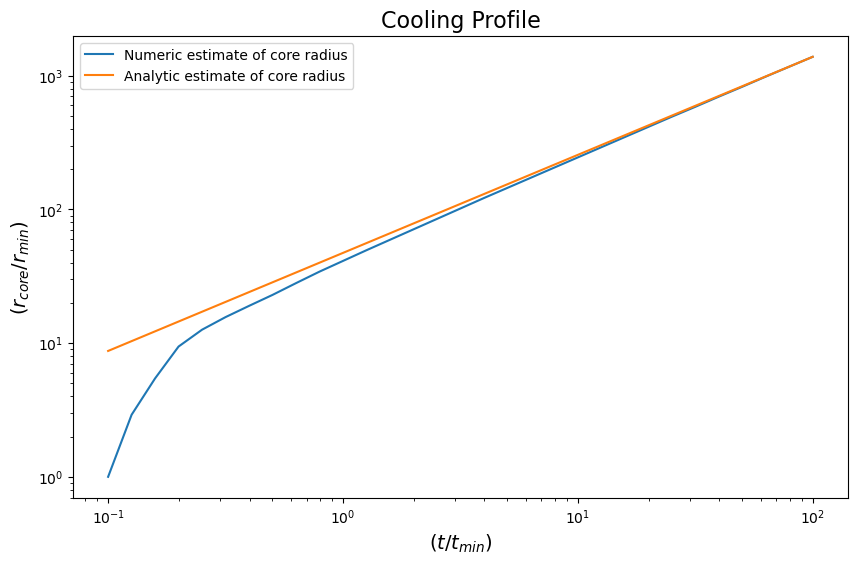

In [46]:
"""
Now our plan is to check the properties of the core radius. As clear from the temperature profile at different times, the center
cools slowly while that outside remains at the original temperature ( the information about the absence of the central BH takes
some time to diffuse to the large radii). We want to numerically estimate the core radii and the rate of expansion of the core 
radii. The core radii can be calcuated by checking the derivative of the T(r), namely (d log T(r)/ dr) since T(r) only changes
if we move outside the core.
"""

from scipy.interpolate import interp1d

# Define the target slope and the midpoint threshold
analytic_slope = -7/11 # this the analytic estimate for the core radius vs temperature
threshold = analytic_slope / 2  # -7/22

central_radii = []
# We use a finer r-grid for interpolation to get a precise crossing point
r_fine = np.geomspace(r.min(), r.max(), 2000) 

for i in range(solution.t.size):
    T_data = solution.y[:, i]
    
    # 1. Create an interpolation function for T(r)
    # Using log-log interpolation is more accurate for power laws
    f_interp = interp1d(np.log(r), np.log(T_data), kind='cubic')
    log_T_fine = f_interp(np.log(r_fine))
    
    # 2. Calculate the log-log derivative: d(log T) / d(log r)
    # This directly gives the power-law exponent
    log_r_fine = np.log(r_fine)
    slopes = np.gradient(log_T_fine, log_r_fine)
    
    # 3. Find the first index where the slope drops below the threshold
    # We look for where it "breaks" away from the flat zero-slope
    idx = np.where(slopes < threshold)[0]
    
    if len(idx) > 0:
        central_radii.append(r_fine[idx[0]])
    else:
        central_radii.append(r.min()) # Still flat everywhere

# To check the evolution of the core radius over time:

# --- Plotting ---
plt.figure(figsize=(10, 6))

plt.plot(solution.t, central_radii)
plt.plot(solution.t, central_radii[-1]*(solution.t[-1]/solution.t)**(-11/15))
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"$(t/t_{min})$", fontsize=14)
plt.ylabel(r"$(r_{core}/r_{min})$", fontsize=14)
plt.title("Cooling Profile", fontsize=16)
plt.legend(['Numeric estimate of core radius', 'Analytic estimate of core radius'])
plt.show()

In [47]:
# Let's try to fit the slope and see if the numeric result is close to the analyic estimate

reg_t = np.log10(t_for_scaling[-5:])
reg_R = np.log10(central_radii[-5:])
res = stats.linregress( reg_t, reg_R )

print(f"numeric slope: {res.slope:.3f}")
print(f"expected Slope : {11/15:.3f}")

numeric slope: 0.746
expected Slope : 0.733
